# 변동성(25/60/120일) 분석 노트북

여러 티커를 입력받아
1. DB(`us_stock_daily_market_cap`)에서 종가 시계열 추출
2. 25일 / 60일 / 120일 변동성(연율화) 산출 -> 데이터프레임 생성
3. 티커 간 변동성 비교 막대 그래프
4. 특정 티커의 특정 기간 변동성 흐름 시각화

DB 스키마 가정: `(date, ticker, indicator, value)` long-format, `indicator = 'close_price'` 사용


## 0. Import 및 한글 폰트 설정

In [1]:
import pandas as pd
import numpy as np
import pymysql
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from datetime import datetime
import platform

from DATA.stock_invest_function import get_db_host


def set_korean_font():
    system_name = platform.system()
    try:
        if system_name == 'Windows':
            plt.rcParams['font.family'] = 'Malgun Gothic'
        elif system_name == 'Darwin':
            plt.rcParams['font.family'] = 'AppleGothic'
        else:
            # 리눅스 등: 나눔고딕이 설치되어 있으면 사용
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['axes.unicode_minus'] = False


set_korean_font()


## 1. 컨트롤 패널 (여기만 수정해서 사용)

- `TICKER_LIST`: 비교할 티커 리스트
- `START_DATE` / `END_DATE`: 가격 데이터 조회 기간 (END_DATE=None이면 오늘까지)
- `VOL_WINDOWS`: 변동성 산출 윈도우 (거래일 기준)
- `TARGET_TICKER`, `PLOT_START_DATE`, `PLOT_END_DATE`: 특정 기간 흐름 시각화용 파라미터


In [2]:
TICKER_LIST = ['NVDA', 'MU', 'AVGO', 'AMD', 'STX']   # 비교할 티커 리스트

START_DATE = '2005-01-01'   # 가격 데이터 조회 시작일
END_DATE = None              # None이면 오늘까지

VOL_WINDOWS = [25, 60, 120]  # 변동성 산출 윈도우 (거래일 기준)
TRADING_DAYS = 252           # 연율화 기준 거래일수

# 특정 기간 흐름 시각화용 파라미터
TARGET_TICKER = 'NVDA'
PLOT_START_DATE = '2024-01-01'
PLOT_END_DATE = None          # None이면 전체 기간 끝까지


## 2. DB 접속 정보

In [3]:
DB_CONFIG = {
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'host': get_db_host(),
    'port': 3307,
    'database': 'investar'
}


## 3. DB에서 종가 시계열 추출 (long -> wide)

In [4]:
def get_price_data(tickers: list, start_date: str, end_date: str = None) -> pd.DataFrame:
    """
    여러 티커의 종가(close_price) 시계열을 DB에서 조회하여
    wide-format DataFrame으로 반환 (index=date, columns=ticker)

    Parameters
    ----------
    tickers : list
        조회할 티커 리스트
    start_date : str
        조회 시작일 ('YYYY-MM-DD')
    end_date : str or None
        조회 종료일. None이면 오늘 날짜까지

    Returns
    -------
    pd.DataFrame
        index=date, columns=ticker, values=close_price
    """
    if end_date is None:
        end_date = datetime.now().strftime('%Y-%m-%d')

    connection = pymysql.connect(**DB_CONFIG, charset='utf8mb4')

    try:
        # IN 절 placeholder 동적 생성
        placeholders = ', '.join(['%s'] * len(tickers))

        query = f"""
            SELECT date, ticker, value AS close_price
            FROM us_stock_daily_market_cap
            WHERE indicator = 'close_price'
              AND ticker IN ({placeholders})
              AND date BETWEEN %s AND %s
            ORDER BY date, ticker
        """

        params = tuple(tickers) + (start_date, end_date)

        with connection.cursor() as cursor:
            cursor.execute(query, params)
            rows = cursor.fetchall()

        if not rows:
            print("조회된 데이터가 없습니다. 티커/기간을 확인하세요.")
            return pd.DataFrame()

        df_long = pd.DataFrame(rows, columns=['date', 'ticker', 'close_price'])
        df_long['date'] = pd.to_datetime(df_long['date'])
        df_long['close_price'] = df_long['close_price'].astype(float)

        # long -> wide (pivot)
        price_wide = df_long.pivot_table(
            index='date', columns='ticker', values='close_price'
        )
        price_wide.sort_index(inplace=True)

        # 조회했지만 DB에 없는 티커 확인
        missing = set(tickers) - set(price_wide.columns)
        if missing:
            print(f"[경고] DB에서 조회되지 않은 티커: {sorted(missing)}")

        return price_wide

    except Exception as e:
        print(f"Error fetching price data: {str(e)}")
        return pd.DataFrame()

    finally:
        connection.close()


## 4. 변동성(25/60/120일) 데이터프레임 생성

In [5]:
def calculate_volatility(
    price_df: pd.DataFrame,
    windows: list = VOL_WINDOWS,
    trading_days: int = TRADING_DAYS
) -> dict:
    """
    종가 데이터로부터 rolling 변동성(연율화, %) 산출

    Parameters
    ----------
    price_df : pd.DataFrame
        index=date, columns=ticker (종가)
    windows : list
        변동성 산출 윈도우 리스트 (예: [25, 60, 120])
    trading_days : int
        연율화 기준 거래일수 (기본 252)

    Returns
    -------
    dict
        {
          'daily_log_return': DataFrame (일별 로그수익률),
          'volatility_full': dict{window: DataFrame} (일자별 rolling 변동성, 전체 기간),
          'volatility_summary': DataFrame (티커별 최신 변동성, 비교용 요약 테이블)
        }
    """
    if price_df.empty:
        print("가격 데이터가 비어있어 변동성을 계산할 수 없습니다.")
        return {}

    # 일별 로그수익률
    log_return = np.log(price_df / price_df.shift(1))

    volatility_full = {}
    for w in windows:
        # rolling 표준편차 -> 연율화(%) 변환
        vol = log_return.rolling(window=w, min_periods=w).std() * np.sqrt(trading_days) * 100
        volatility_full[w] = vol

    # 요약 테이블: 각 티커의 "가장 최근" 변동성 값 (각 window별로 마지막 non-NaN 값)
    summary_rows = {}
    for ticker in price_df.columns:
        row = {}
        for w in windows:
            series = volatility_full[w][ticker].dropna()
            row[f'vol_{w}d'] = series.iloc[-1] if not series.empty else np.nan
        summary_rows[ticker] = row

    volatility_summary = pd.DataFrame(summary_rows).T
    volatility_summary.index.name = 'ticker'
    volatility_summary = volatility_summary.round(2)

    return {
        'daily_log_return': log_return,
        'volatility_full': volatility_full,
        'volatility_summary': volatility_summary
    }


## 5. 티커 간 변동성 비교 막대 그래프

In [6]:
def plot_volatility_bar_comparison(
    volatility_summary: pd.DataFrame,
    windows: list = VOL_WINDOWS,
    title: str = "티커별 변동성 비교 (연율화, %)"
):
    """
    volatility_summary DataFrame(티커 x window)을 기반으로
    티커별 25/60/120일 변동성을 그룹 막대 그래프로 비교

    Parameters
    ----------
    volatility_summary : pd.DataFrame
        calculate_volatility()['volatility_summary'] 결과
    windows : list
        비교할 윈도우 리스트
    """
    if volatility_summary.empty:
        print("비교할 변동성 데이터가 없습니다.")
        return

    tickers = volatility_summary.index.tolist()
    n_tickers = len(tickers)
    n_windows = len(windows)

    x = np.arange(n_tickers)
    bar_width = 0.8 / n_windows

    fig, ax = plt.subplots(figsize=(max(8, n_tickers * 1.3), 6))

    colors = plt.cm.viridis(np.linspace(0.15, 0.85, n_windows))

    for i, w in enumerate(windows):
        col = f'vol_{w}d'
        values = volatility_summary[col].values
        offset = (i - (n_windows - 1) / 2) * bar_width
        bars = ax.bar(x + offset, values, width=bar_width,
                      label=f'{w}일 변동성', color=colors[i])
        # 값 라벨 표시
        for bar, val in zip(bars, values):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                        f'{val:.1f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(tickers, fontsize=10)
    ax.set_ylabel('연율화 변동성 (%)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()


## 6. 특정 기업의 특정 기간 변동성 흐름 시각화

In [7]:
def plot_volatility_timeseries(
    volatility_full: dict,
    ticker: str,
    start_date: str = None,
    end_date: str = None,
    windows: list = VOL_WINDOWS
):
    """
    특정 티커의 25/60/120일 변동성이 시간에 따라 어떻게 변해왔는지 라인 차트로 표시

    Parameters
    ----------
    volatility_full : dict
        calculate_volatility()['volatility_full'] 결과 ({window: DataFrame})
    ticker : str
        시각화할 티커
    start_date, end_date : str or None
        표시할 기간. None이면 전체 기간
    windows : list
        표시할 윈도우 리스트
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    for w in windows:
        if ticker not in volatility_full[w].columns:
            print(f"[경고] {ticker} 데이터가 {w}일 변동성 결과에 없습니다.")
            continue

        series = volatility_full[w][ticker].dropna()

        if start_date:
            series = series[series.index >= pd.to_datetime(start_date)]
        if end_date:
            series = series[series.index <= pd.to_datetime(end_date)]

        ax.plot(series.index, series.values, label=f'{w}일 변동성', linewidth=1.8)

    ax.set_title(f'{ticker} 변동성 추이 (연율화, %)', fontsize=13, fontweight='bold')
    ax.set_xlabel('날짜')
    ax.set_ylabel('연율화 변동성 (%)')
    ax.legend()
    ax.grid(linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()


## 7. 실행

1. 가격 데이터 조회
2. 변동성 계산 및 요약 테이블 확인
3. 티커 간 비교 막대 그래프
4. 특정 티커/기간 변동성 흐름


In [8]:
print(f"대상 티커: {TICKER_LIST}")
price_df = get_price_data(TICKER_LIST, START_DATE, END_DATE)

if not price_df.empty:
    print(f"조회된 데이터 기간: {price_df.index.min().date()} ~ {price_df.index.max().date()}")
    print(f"조회된 티커: {list(price_df.columns)}")

price_df.tail()


대상 티커: ['NVDA', 'MU', 'AVGO', 'AMD', 'STX']
조회된 데이터 기간: 2015-01-02 ~ 2026-07-27
조회된 티커: ['AMD', 'AVGO', 'MU', 'NVDA', 'STX']


ticker,AMD,AVGO,MU,NVDA,STX
date,,,,,
2026-07-21,544.430000,386.500000,970.820000,207.290000,NaN
2026-07-22,552.330000,396.810000,959.480000,212.060000,NaN
2026-07-23,539.690002,392.470001,990.210022,208.759995,913.359985
2026-07-24,521.950012,381.920013,920.950012,206.839996,851.690002
2026-07-27,494.950012,383.220001,900.200012,196.509995,816.989990


In [18]:
# price_df.to_csv(r"C:\Users\82108\OneDrive\INVESTMENT\미국주식\raw_data\semicon_price.csv")

In [9]:
result = calculate_volatility(price_df, windows=VOL_WINDOWS)

volatility_summary = result['volatility_summary']
volatility_full = result['volatility_full']
daily_log_return = result['daily_log_return']

print("[변동성 요약 테이블 (최신 기준, 연율화 %)]")
volatility_summary


[변동성 요약 테이블 (최신 기준, 연율화 %)]


,vol_25d,vol_60d,vol_120d
ticker,,,
AMD,71.37,82.35,77.07
AVGO,43.55,54.85,49.18
MU,104.50,108.53,91.56
NVDA,38.65,42.02,40.03
STX,70.14,76.32,75.99


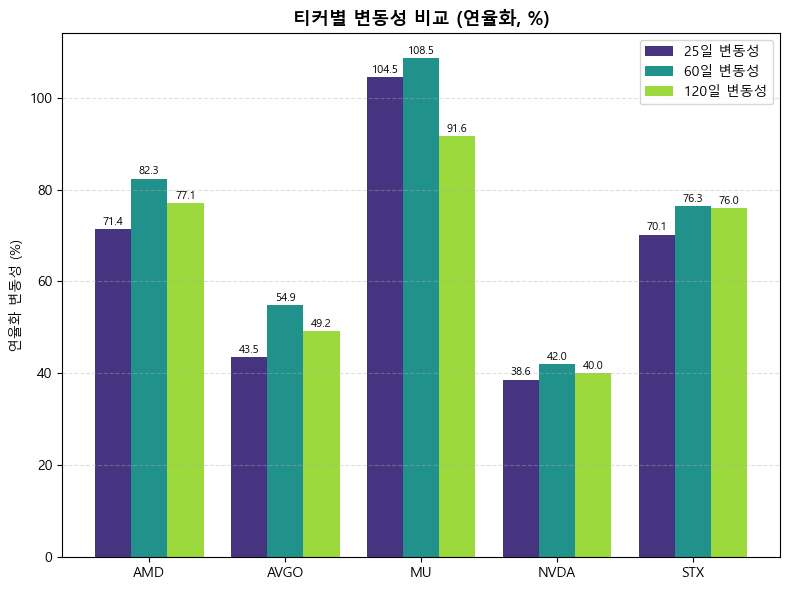

In [10]:
plot_volatility_bar_comparison(volatility_summary, windows=VOL_WINDOWS)


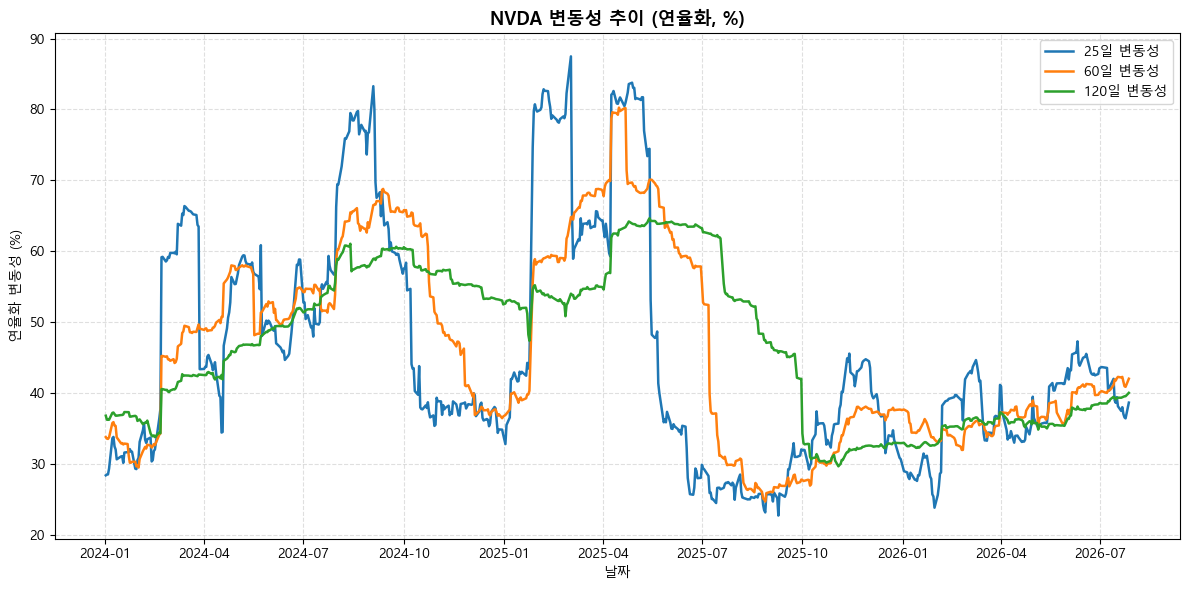

In [11]:
plot_volatility_timeseries(
    volatility_full,
    ticker=TARGET_TICKER,
    start_date=PLOT_START_DATE,
    end_date=PLOT_END_DATE,
    windows=VOL_WINDOWS
)


## 8. 특정일 변동성만 지정해서 회사별 비교

특정 하루(예: '2024-11-15')를 지정하면, 그 날짜 기준 25/60/120일 변동성을 회사별로 비교합니다.
해당 날짜가 휴장일 등으로 데이터가 없으면 **그 이전의 가장 가까운 거래일** 값을 자동으로 사용합니다.


In [12]:
def get_volatility_on_date(
    volatility_full: dict,
    target_date: str,
    windows: list = VOL_WINDOWS
) -> pd.DataFrame:
    """
    특정 날짜 기준으로 티커별 25/60/120일 변동성 값을 추출

    target_date가 휴장일 등으로 정확히 존재하지 않으면,
    해당 날짜 '이전'의 가장 가까운 거래일 값을 사용한다 (미래 데이터 참조 방지).

    Parameters
    ----------
    volatility_full : dict
        calculate_volatility()['volatility_full'] 결과 ({window: DataFrame})
    target_date : str
        조회하고 싶은 날짜 ('YYYY-MM-DD')
    windows : list
        비교할 윈도우 리스트

    Returns
    -------
    pd.DataFrame
        index=ticker, columns=[f'vol_{w}d' for w in windows]
        + 'as_of_date' 컬럼 (실제로 사용된 거래일, 참고용)
    """
    target_ts = pd.to_datetime(target_date)

    rows = {}
    used_dates = {}

    for w in windows:
        vol_df = volatility_full[w]

        # target_date 이하(<=)인 가장 마지막 거래일 탐색
        available_dates = vol_df.index[vol_df.index <= target_ts]
        if len(available_dates) == 0:
            print(f"[경고] {w}일 변동성: {target_date} 이전에 사용 가능한 데이터가 없습니다.")
            continue

        actual_date = available_dates.max()
        row = vol_df.loc[actual_date]

        for ticker, value in row.items():
            rows.setdefault(ticker, {})[f'vol_{w}d'] = value
            used_dates.setdefault(ticker, {})[f'vol_{w}d_date'] = actual_date

    if not rows:
        print("지정한 날짜 기준으로 조회 가능한 변동성 데이터가 없습니다.")
        return pd.DataFrame()

    result_df = pd.DataFrame(rows).T
    result_df.index.name = 'ticker'
    result_df = result_df.round(2)

    # 실제 사용된 날짜가 요청일과 다른 경우 안내
    for w in windows:
        col = f'vol_{w}d_date'
        dates_for_w = {t: d.get(col) for t, d in used_dates.items() if col in d}
        distinct_dates = set(pd.Timestamp(d).date() for d in dates_for_w.values())
        if distinct_dates and (len(distinct_dates) > 1 or list(distinct_dates)[0] != target_ts.date()):
            print(f"[안내] {w}일 변동성은 {target_date}가 아닌 실제 거래일 기준값입니다: "
                  f"{sorted(str(d) for d in distinct_dates)}")

    return result_df


In [13]:
def plot_volatility_on_date(
    volatility_full: dict,
    target_date: str,
    windows: list = VOL_WINDOWS,
    title: str = None
):
    """
    특정일 기준 변동성을 회사별로 비교하는 막대 그래프

    Parameters
    ----------
    volatility_full : dict
        calculate_volatility()['volatility_full'] 결과
    target_date : str
        비교 기준일 ('YYYY-MM-DD')
    windows : list
        비교할 윈도우 리스트
    """
    vol_on_date = get_volatility_on_date(volatility_full, target_date, windows)

    if vol_on_date.empty:
        return

    if title is None:
        title = f"{target_date} 기준 티커별 변동성 비교 (연율화, %)"

    tickers = vol_on_date.index.tolist()
    n_tickers = len(tickers)
    n_windows = len(windows)

    x = np.arange(n_tickers)
    bar_width = 0.8 / n_windows

    fig, ax = plt.subplots(figsize=(max(8, n_tickers * 1.3), 6))
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, n_windows))

    for i, w in enumerate(windows):
        col = f'vol_{w}d'
        if col not in vol_on_date.columns:
            continue
        values = vol_on_date[col].values
        offset = (i - (n_windows - 1) / 2) * bar_width
        bars = ax.bar(x + offset, values, width=bar_width,
                      label=f'{w}일 변동성', color=colors[i])
        for bar, val in zip(bars, values):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                        f'{val:.1f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(tickers, fontsize=10)
    ax.set_ylabel('연율화 변동성 (%)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

    return vol_on_date


### 실행 예시

`TARGET_DATE`만 원하는 날짜로 바꿔서 실행하면 됩니다.


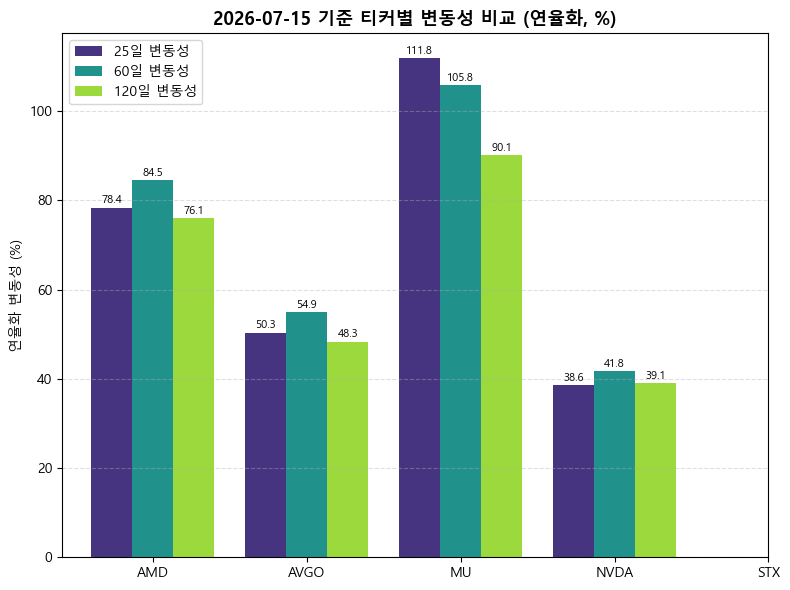

,vol_25d,vol_60d,vol_120d
ticker,,,
AMD,78.39,84.51,76.06
AVGO,50.33,54.88,48.31
MU,111.85,105.85,90.09
NVDA,38.62,41.76,39.10
STX,NaN,NaN,NaN


In [14]:
TARGET_DATE = '2026-07-15'  # 비교하고 싶은 특정일6

vol_on_target_date = plot_volatility_on_date(
    volatility_full,
    target_date=TARGET_DATE,
    windows=VOL_WINDOWS
)

vol_on_target_date


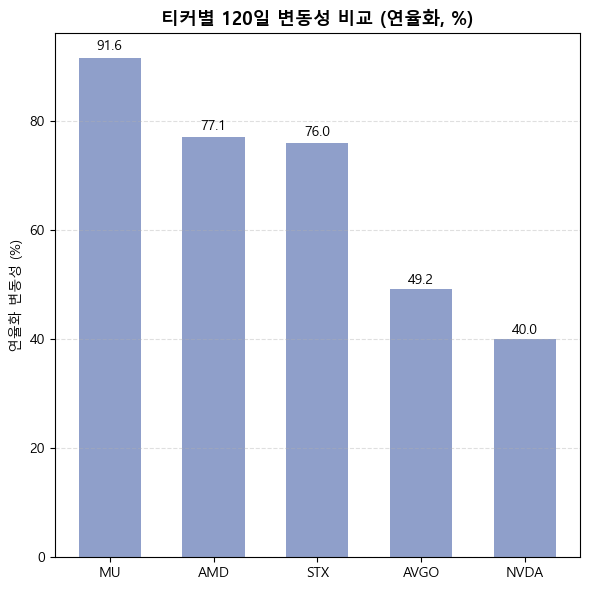

ticker
MU      91.56
AMD     77.07
STX     75.99
AVGO    49.18
NVDA    40.03
Name: vol_120d, dtype: float64

In [15]:
def plot_single_window_comparison(
    volatility_summary: pd.DataFrame,
    window: int,
    title: str = None,
    color: str = '#8f9fca'
):
    """
    단일 윈도우(예: 120일) 변동성만 골라서 티커별로 비교하는 막대 그래프

    Parameters
    ----------
    volatility_summary : pd.DataFrame
        calculate_volatility()['volatility_summary'] 결과 (티커 x window)
    window : int
        비교할 단일 윈도우 (예: 25, 60, 120)
    title : str or None
        그래프 제목. None이면 자동 생성
    color : str
        막대 색상

    Returns
    -------
    pd.Series
        해당 윈도우의 티커별 변동성 값 (내림차순 정렬)
    """
    col = f'vol_{window}d'

    if col not in volatility_summary.columns:
        print(f"[경고] volatility_summary에 '{col}' 컬럼이 없습니다. "
              f"사용 가능한 컬럼: {list(volatility_summary.columns)}")
        return pd.Series(dtype=float)

    values = volatility_summary[col].dropna().sort_values(ascending=False)

    if values.empty:
        print(f"{window}일 변동성 데이터가 없습니다.")
        return values

    if title is None:
        title = f"티커별 {window}일 변동성 비교 (연율화, %)"

    fig, ax = plt.subplots(figsize=(max(6, len(values) * 1.2), 6))

    bars = ax.bar(values.index, values.values, color=color, width=0.6)

    for bar, val in zip(bars, values.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + val * 0.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10)

    ax.set_ylabel('연율화 변동성 (%)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

    return values


# 실행 예시 (120일 변동성만 비교)
vol_120d = plot_single_window_comparison(volatility_summary, window=120)
vol_120d